In [ ]:
!pip install \
tensorflow==2.20.0 \
keras==3.12.0 \
scikit-learn==1.7.2 \
numpy==2.3.3 \
pandas==2.3.3 \
xgboost==3.1.2 \
joblib==1.5.2 \
h5py==3.15.1 \
scipy==1.16.3

In [ ]:
import os, json

kaggle_token = {
    "username": "gibsonmel",
    "key": "KGAT_c51f015cbedd8440bfb75727ded2582a"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_token, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d ekkykharismadhany/csecicids2018-cleaned
!unzip -o csecicids2018-cleaned.zip

Dataset URL: https://www.kaggle.com/datasets/ekkykharismadhany/csecicids2018-cleaned
License(s): copyright-authors
 99% 125M/126M [00:00<00:00, 651MB/s] 
100% 126M/126M [00:00<00:00, 644MB/s]
Archive:  csecicids2018-cleaned.zip
  inflating: cleaned_ids2018_sampled.csv  


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [ ]:
df = pd.read_csv("cleaned_ids2018_sampled.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1252846, 79)


,Unnamed: 0,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,146275,3389,6,5206015,9,11,1213,1948,661,0,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,1
1,512109,443,6,60991608,14,14,1211,3396,875,0,...,20,116504.666667,117401.762867,356150,68519,1.000239e+07,1.665183e+04,10009249,9968397,1
2,807703,53,17,27292,1,1,45,163,45,45,...,8,0.000000,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,1
3,491912,443,6,70343424,17,20,1118,5653,258,0,...,20,527683.500000,386311.526445,800847,254520,3.457024e+07,3.406089e+07,58654921,10485549,1
4,858679,53,17,137267,2,2,94,214,47,47,...,8,0.000000,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,1


In [ ]:
features = [
    # Flow structure
    "Flow Duration",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "Fwd Pkts/s",
    "Bwd Pkts/s",

    # Packet size variability
    "Fwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Mean",
    "Bwd Pkt Len Std",
    "Pkt Len Std",
    "Pkt Len Var",

    # Timing behavior
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Mean",
    "Bwd IAT Mean",

    # TCP behavior
    "SYN Flag Cnt",
    "ACK Flag Cnt",
    "RST Flag Cnt",
    "PSH Flag Cnt"
]

df = df[features + ["Label"]].dropna()

In [ ]:
df["Label"] = df["Label"].apply(lambda x: 0 if x == 1 else 1)

print(df["Label"].value_counts())

Label
0    971016
1    281830
Name: count, dtype: int64


In [ ]:
X = df[features]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scapy_scaler.pkl")

['scapy_scaler.pkl']

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)

joblib.dump(xgb_model, "scapy_xgb_model.pkl")

['scapy_xgb_model.pkl']

In [ ]:
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:,1]
xgb_preds = (xgb_probs > 0.5).astype(int)

print("===== XGBOOST RESULTS =====")
print("Accuracy :", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds))
print("Recall   :", recall_score(y_test, xgb_preds))
print("F1 Score :", f1_score(y_test, xgb_preds))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_probs))

===== XGBOOST RESULTS =====
Accuracy : 0.9925928882148701
Precision: 0.973045681755068
Recall   : 0.9946244189759784
F1 Score : 0.9837167272025408
ROC-AUC  : 0.9986506831493702


In [ ]:
X_train_benign = X_train_scaled[y_train == 0]
input_dim = X_train_benign.shape[1]

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_benign.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(64, activation="relu")(input_layer)
x = BatchNormalization()(x)
x = Dense(32, activation="relu")(x)
x = BatchNormalization()(x)
x = Dense(16, activation="relu")(x)

latent = Dense(4, activation="relu")(x)

# Decoder
x = Dense(16, activation="relu")(latent)
x = BatchNormalization()(x)
x = Dense(32, activation="relu")(x)
x = BatchNormalization()(x)
x = Dense(64, activation="relu")(x)

output_layer = Dense(input_dim, activation="linear")(x)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer="adam", loss="mse")

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

autoencoder.fit(
    X_train_benign,
    X_train_benign,
    epochs=100,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.5381 - val_loss: 0.1573
Epoch 2/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4788 - val_loss: 0.2030
Epoch 3/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4646 - val_loss: 0.0850
Epoch 4/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4175 - val_loss: 0.1200
Epoch 5/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4086 - val_loss: 0.0645
Epoch 6/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4057 - val_loss: 0.0623
Epoch 7/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4089 - val_loss: 0.0537
Epoch 8/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4014 - val_loss: 0.0530
Epoch 9/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3991 - val_loss: 0.0609
Epoch 10/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3948 - val_loss: 0.0750
Epoch 11/100
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3956 - val_loss: 0.0496
Epoch 12/100
1366/

In [ ]:
autoencoder.save("scapy_autoencoder.h5")

In [ ]:
from sklearn.metrics import roc_curve

recon_test = autoencoder.predict(X_test_scaled)
mse_test = np.mean(np.power(X_test_scaled - recon_test, 2), axis=1)

fpr, tpr, thresholds = roc_curve(y_test, mse_test)

optimal_idx = np.argmax(tpr - fpr)
threshold = thresholds[optimal_idx]

print("Optimal Threshold:", threshold)

import joblib
joblib.dump(threshold, "scapy_ae_threshold.pkl")

7831/7831 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step
Optimal Threshold: 0.01546501624192897


['scapy_ae_threshold.pkl']

In [ ]:
recon_test = autoencoder.predict(X_test_scaled)
mse_test = np.mean(np.power(X_test_scaled - recon_test, 2), axis=1)

ae_preds = (mse_test > threshold).astype(int)

print("\n===== AUTOENCODER RESULTS =====")
print("Accuracy :", accuracy_score(y_test, ae_preds))
print("Precision:", precision_score(y_test, ae_preds))
print("Recall   :", recall_score(y_test, ae_preds))
print("F1 Score :", f1_score(y_test, ae_preds))
print("ROC-AUC  :", roc_auc_score(y_test, mse_test))

7831/7831 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step

===== AUTOENCODER RESULTS =====
Accuracy : 0.8600590653310453
Precision: 0.6263839280416751
Recall   : 0.9364865344356527
F1 Score : 0.7506701650348059
ROC-AUC  : 0.8865649109935667


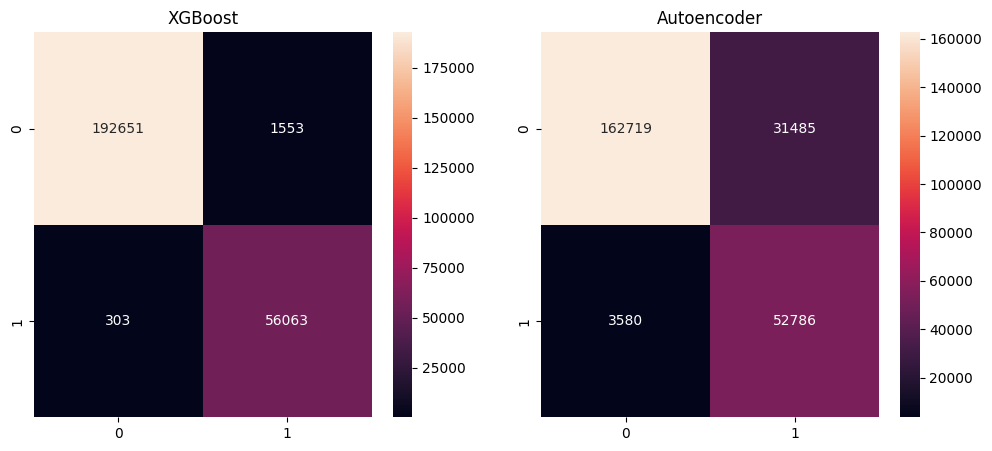

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, xgb_preds),
            annot=True, fmt="d", ax=axes[0])
axes[0].set_title("XGBoost")

sns.heatmap(confusion_matrix(y_test, ae_preds),
            annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Autoencoder")

plt.show()

In [ ]:
from google.colab import files

files.download("scapy_scaler.pkl")
files.download("scapy_xgb_model.pkl")
files.download("scapy_autoencoder.h5")
files.download("scapy_ae_threshold.pkl")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

In [ ]:
# XGB predictions
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_preds = (xgb_probs > 0.5).astype(int)

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("===== XGBOOST METRICS =====")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_auc)

===== XGBOOST METRICS =====
Accuracy : 0.9925928882148701
Precision: 0.973045681755068
Recall   : 0.9946244189759784
F1 Score : 0.9837167272025408
ROC-AUC  : 0.9986506831493702


In [ ]:
# Reconstruction
reconstructions = autoencoder.predict(X_test_scaled)
mse_test = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# Predictions using threshold
ae_preds = (mse_test > threshold).astype(int)

ae_accuracy = accuracy_score(y_test, ae_preds)
ae_precision = precision_score(y_test, ae_preds)
ae_recall = recall_score(y_test, ae_preds)
ae_f1 = f1_score(y_test, ae_preds)
ae_auc = roc_auc_score(y_test, mse_test)

print("\n===== AUTOENCODER METRICS =====")
print("Accuracy :", ae_accuracy)
print("Precision:", ae_precision)
print("Recall   :", ae_recall)
print("F1 Score :", ae_f1)
print("ROC-AUC  :", ae_auc)

7831/7831 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step

===== AUTOENCODER METRICS =====
Accuracy : 0.8600590653310453
Precision: 0.6263839280416751
Recall   : 0.9364865344356527
F1 Score : 0.7506701650348059
ROC-AUC  : 0.8865649109935667


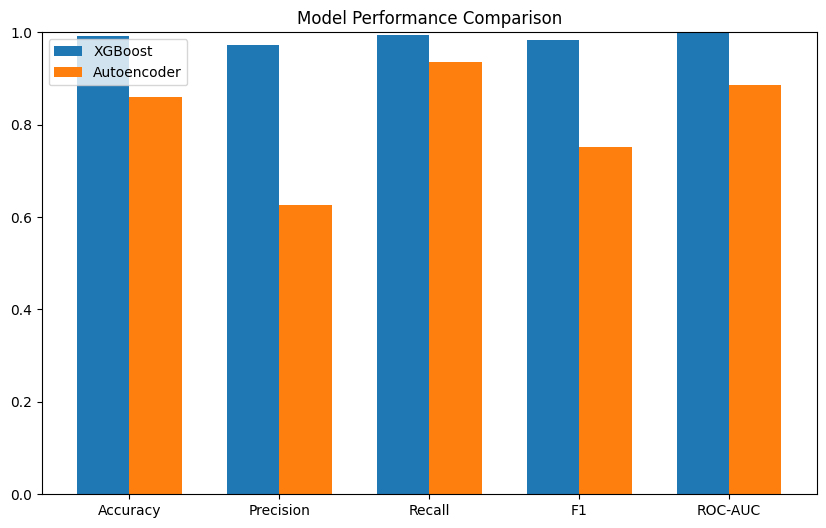

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_auc]
ae_scores = [ae_accuracy, ae_precision, ae_recall, ae_f1, ae_auc]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, xgb_scores, width, label="XGBoost")
plt.bar(x + width/2, ae_scores, width, label="Autoencoder")

plt.xticks(x, metrics)
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

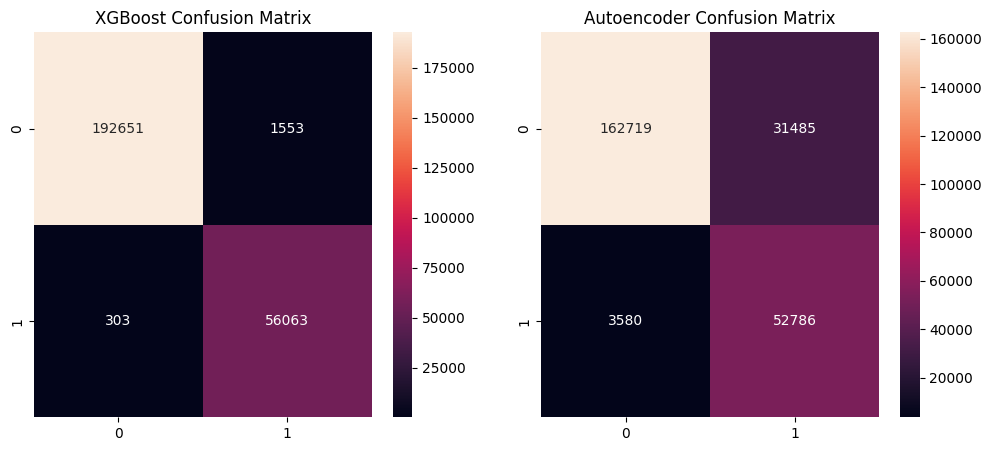

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, xgb_preds),
            annot=True, fmt="d", ax=axes[0])
axes[0].set_title("XGBoost Confusion Matrix")

sns.heatmap(confusion_matrix(y_test, ae_preds),
            annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Autoencoder Confusion Matrix")

plt.show()

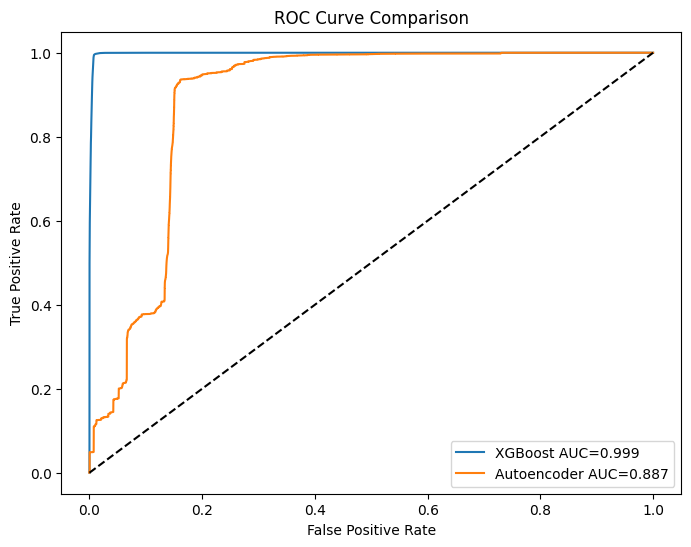

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_ae, tpr_ae, _ = roc_curve(y_test, mse_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC={xgb_auc:.3f}")
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder AUC={ae_auc:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

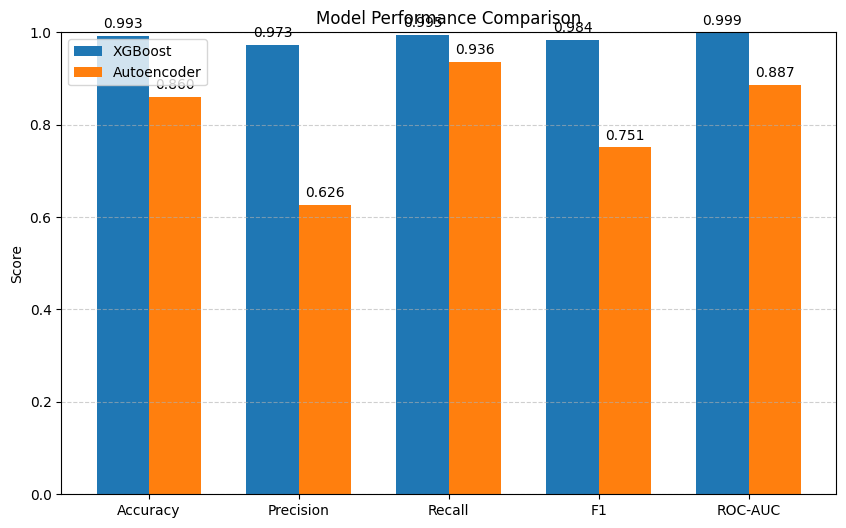

In [ ]:
plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, xgb_scores, width, label="XGBoost")
bars2 = plt.bar(x + width/2, ae_scores, width, label="Autoencoder")

plt.xticks(x, metrics)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.01,
                 f"{height:.3f}",
                 ha='center', va='bottom')

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

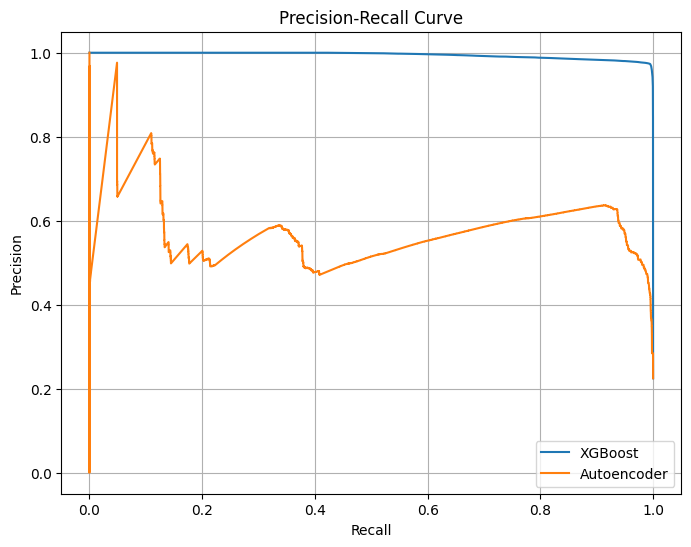

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_probs)
precision_ae, recall_ae, _ = precision_recall_curve(y_test, mse_test)

plt.figure(figsize=(8,6))
plt.plot(recall_xgb, precision_xgb, label="XGBoost")
plt.plot(recall_ae, precision_ae, label="Autoencoder")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

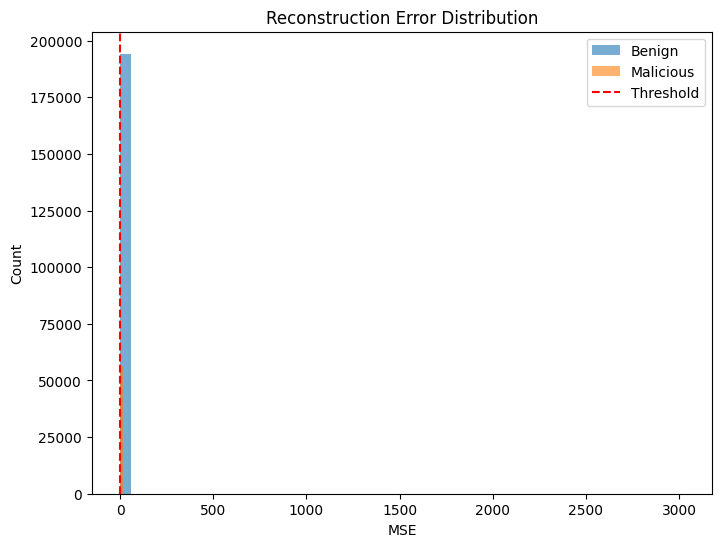

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(mse_test[y_test==0], bins=50, alpha=0.6, label="Benign")
plt.hist(mse_test[y_test==1], bins=50, alpha=0.6, label="Malicious")

plt.axvline(threshold, color="red", linestyle="--", label="Threshold")

plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Count")
plt.legend()
plt.show()

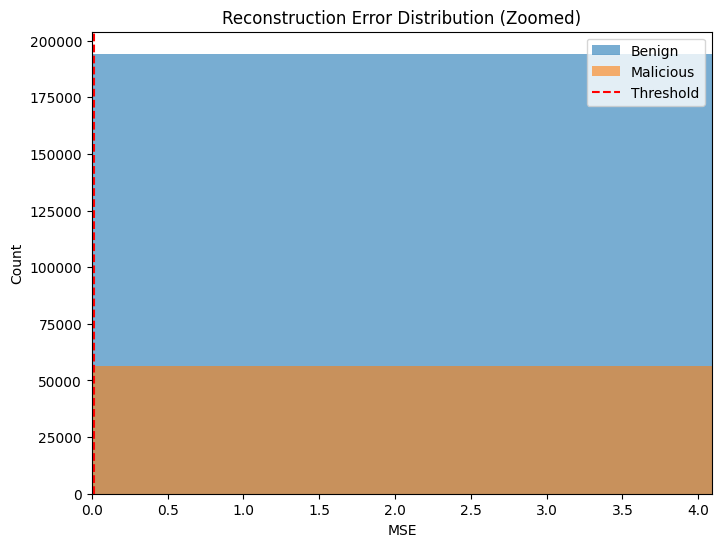

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

upper_limit = np.percentile(mse_test, 99)

plt.figure(figsize=(8,6))

plt.hist(mse_test[y_test==0], bins=50, alpha=0.6, label="Benign")
plt.hist(mse_test[y_test==1], bins=50, alpha=0.6, label="Malicious")

plt.axvline(threshold, color="red", linestyle="--", label="Threshold")

plt.xlim(0, upper_limit)

plt.title("Reconstruction Error Distribution (Zoomed)")
plt.xlabel("MSE")
plt.ylabel("Count")
plt.legend()
plt.show()